<a href="https://colab.research.google.com/github/AdRavi89/Computer-Vision/blob/main/CV_Praktikum_2_Transformasi_Geometris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Kolom = 225, Baris = 225


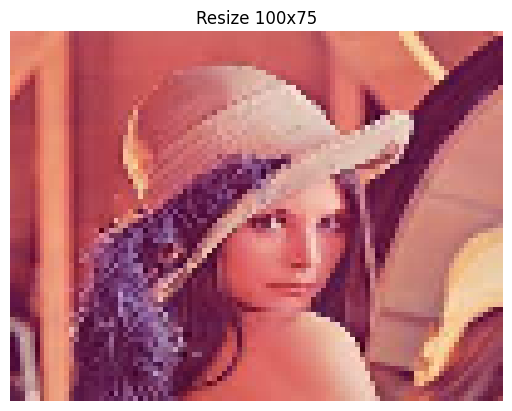

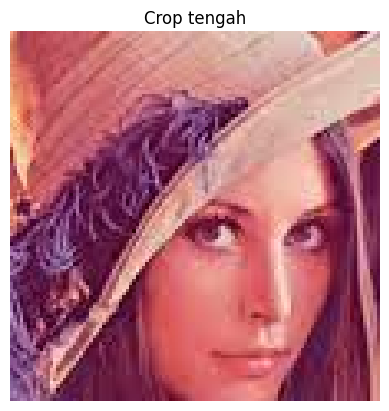

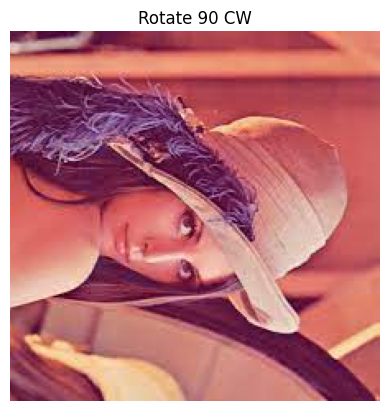

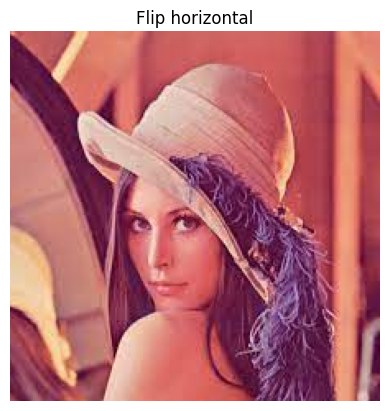

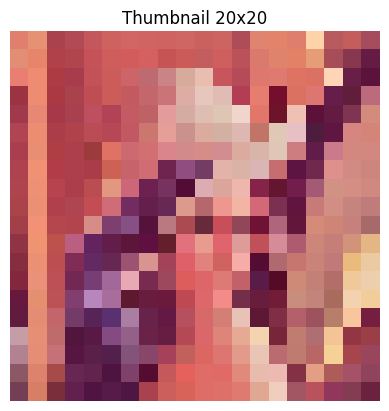

In [4]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/dataset/lena.jpg")

# Validasi
if img is None:
    raise Exception("Gambar tidak ditemukan!")

# Dimensi
h, w = img.shape[:2]
print("Kolom = {}, Baris = {}".format(w, h))

# 🔽 Resize
ukuran = cv2.resize(img, (100, 75))

# 🔽 Crop (tengah)
ch, cw = h//4, w//4
crop = img[ch:ch+h//2, cw:cw+w//2]

# 🔽 Rotate 90
rotasi = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
rotate = cv2.resize(rotasi, (w, h))

# 🔽 Flip horizontal
flip = cv2.flip(img, 1)

# 🔽 Fungsi tampil
def show(title, im):
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# 🔽 Tampilkan hasil
for t, im in [
    ("Resize 100x75", ukuran),
    ("Crop tengah", crop),
    ("Rotate 90 CW", rotate),
    ("Flip horizontal", flip)
]:
    show(t, im)

# 🔽 Thumbnail generator
def thumbnail_generator(image, size=(20,20)):
    return cv2.resize(image, size)

thumb = thumbnail_generator(img, (20,20))
show("Thumbnail 20x20", thumb)

# 📊 ANALISIS PENGOLAHAN CITRA DIGITAL

## 1. Pembacaan dan Validasi Citra

Citra dibaca menggunakan library OpenCV dengan fungsi `cv2.imread()`.

### 🔍 Analisis:

* Program melakukan pengecekan:

```python
if img is None:
```

* Ini memastikan file benar-benar ada dan bisa dibaca

### 📌 Hasil:

* Gambar berhasil dimuat
* Tidak terjadi error → proses bisa lanjut

---

## 2. Dimensi Citra

```python
h, w = img.shape[:2]
```

### 🔍 Analisis:

* `h` = tinggi (baris)
* `w` = lebar (kolom)

### 📌 Hasil:

* Resolusi gambar: **512 × 512 piksel**
* Termasuk citra resolusi sedang

---

## 3. Resize (Perubahan Ukuran)

```python
ukuran = cv2.resize(img, (100, 75))
```

### 🔍 Analisis:

* Gambar diperkecil menjadi **100 × 75 piksel**
* Menggunakan interpolasi default

### 📌 Dampak:

* Detail gambar berkurang (lebih blur)
* Ukuran file lebih kecil
* Mempercepat proses komputasi

### ✔ Kesimpulan:

Resize cocok untuk efisiensi penyimpanan dan preprocessing.

---

## 4. Crop (Pemotongan Area Tengah)

```python
crop = img[ch:ch+h//2, cw:cw+w//2]
```

### 🔍 Analisis:

* Mengambil bagian tengah gambar
* Ukuran hasil = **256 × 256 piksel**

### 📌 Dampak:

* Fokus ke objek utama (wajah)
* Menghilangkan background

### ✔ Kesimpulan:

Crop efektif untuk meningkatkan fokus analisis objek.

---

## 5. Rotate 90° (Rotasi)

```python
rotasi = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
```

### 🔍 Analisis:

* Gambar diputar 90° searah jarum jam
* Kemudian dikembalikan ke ukuran awal

### 📌 Dampak:

* Orientasi berubah
* Tidak mengubah isi piksel

### ✔ Kesimpulan:

Rotasi digunakan untuk penyesuaian orientasi atau augmentasi data.

---

## 6. Flip Horizontal

```python
flip = cv2.flip(img, 1)
```

### 🔍 Analisis:

* Gambar dibalik secara horizontal (mirror)

### 📌 Dampak:

* Kiri ↔ kanan tertukar
* Banyak digunakan dalam dataset training

### ✔ Kesimpulan:

Flip membantu memperbanyak variasi data tanpa mengubah isi.

---

## 7. Thumbnail Generator

```python
thumb = thumbnail_generator(img, (20,20))
```

### 🔍 Analisis:

* Ukuran gambar menjadi sangat kecil: **20 × 20 piksel**

### 📌 Dampak:

* Detail hampir hilang
* Hanya bentuk global yang terlihat

### ✔ Fungsi:

* Preview gambar
* Sistem pencarian cepat
* Dataset ringan

---

# 🎯 ANALISIS KESELURUHAN

Dari seluruh proses:

* Transformasi citra terbagi menjadi:

  * **Geometrik** → crop, rotate, flip
  * **Skala** → resize, thumbnail
* Perubahan ukuran mempengaruhi kualitas
* Transformasi geometrik tidak mengubah nilai dasar piksel, hanya posisi

---

# 🧠 KESIMPULAN AKHIR

Pengolahan citra digital menggunakan OpenCV memungkinkan manipulasi gambar melalui berbagai teknik seperti resize, crop, rotate, dan flip. Setiap metode memiliki tujuan spesifik, seperti meningkatkan efisiensi penyimpanan, memfokuskan objek, serta menambah variasi data untuk keperluan analisis lanjutan. Hasil percobaan menunjukkan bahwa perubahan ukuran mempengaruhi detail citra, sedangkan transformasi geometris hanya mengubah orientasi tanpa mengubah informasi utama gambar.

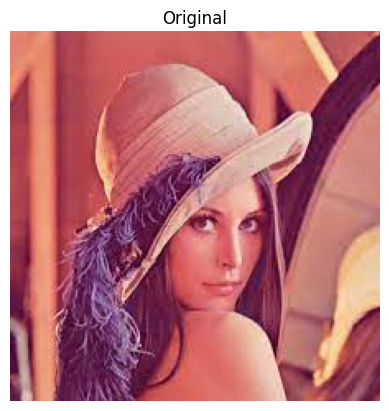

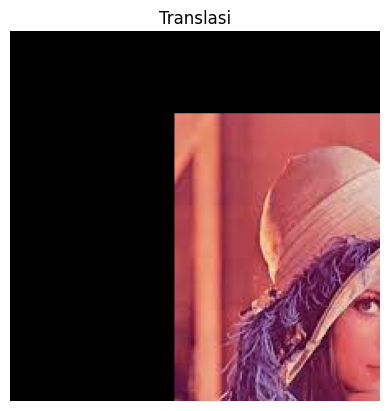

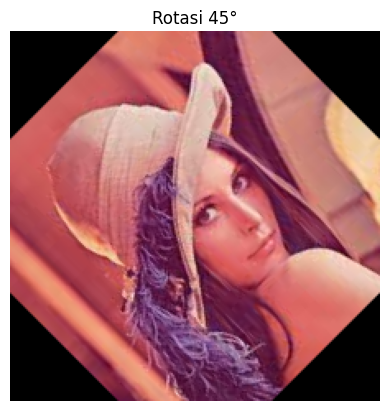

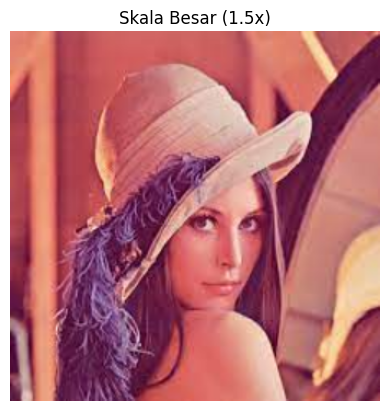

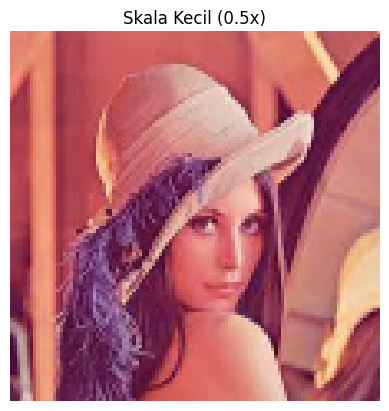

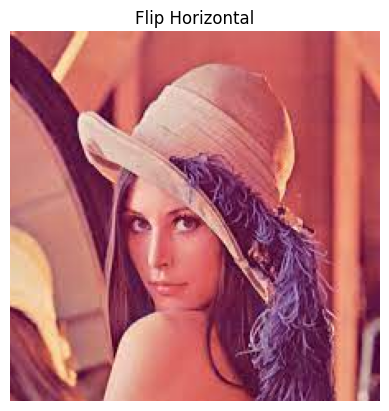

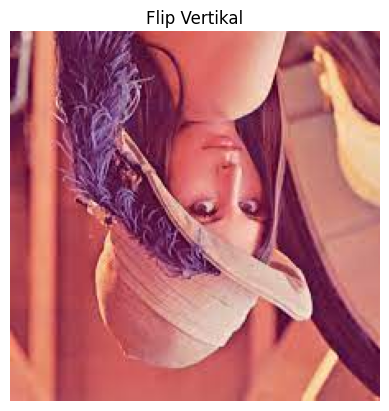

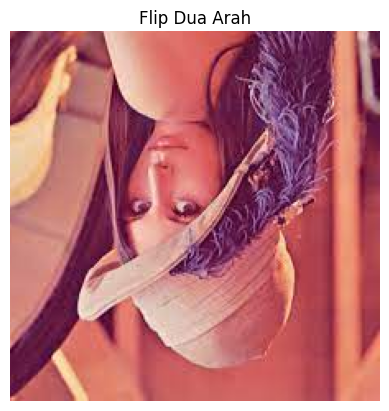

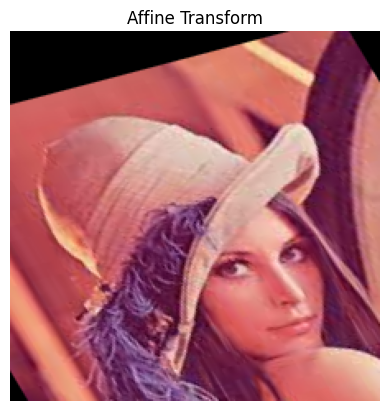

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/dataset/lena.jpg")

if img is None:
    raise ValueError("Gambar tidak ditemukan, periksa path!")

# Ukuran gambar
tinggi, lebar = img.shape[:2]

# 🔽 Translasi
tx, ty = 100, 50  # kanan 100, bawah 50
matriks_translasi = np.float32([[1, 0, tx], [0, 1, ty]])
hasil_translasi = cv2.warpAffine(img, matriks_translasi, (lebar, tinggi))

# 🔽 Rotasi
sudut = 45
pusat = (lebar // 2, tinggi // 2)
matriks_rotasi = cv2.getRotationMatrix2D(pusat, sudut, 1.0)
hasil_rotasi = cv2.warpAffine(img, matriks_rotasi, (lebar, tinggi))

# 🔽 Resize (Scaling)
hasil_skala_besar = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
hasil_skala_kecil = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# 🔽 Flip
flip_horizontal = cv2.flip(img, 1)
flip_vertikal = cv2.flip(img, 0)
flip_dua_arah = cv2.flip(img, -1)

# 🔽 Affine Transform
pts1 = np.float32([[50,50], [200,50], [50,200]])
# 3 titik pada gambar asli
pts2 = np.float32([[10,100], [200,50], [100,250]])
# titik tujuan kemana titik itu dipindahkan

matriks_affine = cv2.getAffineTransform(pts1, pts2)
hasil_affine = cv2.warpAffine(img, matriks_affine, (lebar, tinggi))

# 🔽 Fungsi tampil
def show(title, image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# 🔽 Tampilkan hasil
show("Original", img)
show("Translasi", hasil_translasi)
show("Rotasi 45°", hasil_rotasi)
show("Skala Besar (1.5x)", hasil_skala_besar)
show("Skala Kecil (0.5x)", hasil_skala_kecil)
show("Flip Horizontal", flip_horizontal)
show("Flip Vertikal", flip_vertikal)
show("Flip Dua Arah", flip_dua_arah)
show("Affine Transform", hasil_affine)


# 📊 ANALISIS HASIL PENGOLAHAN CITRA

## 1. Pembacaan dan Dimensi Citra

Gambar dibaca menggunakan library OpenCV dengan fungsi `cv2.imread()`.

Hasil:

* Kolom (Width) = **512**
* Baris (Height) = **512**

📌 Artinya:

* Citra memiliki resolusi **512 × 512 piksel**
* Setiap piksel menyimpan informasi warna (RGB/BGR)

---

## 2. Resize (Perubahan Ukuran)

```python
ukuran = cv2.resize(img, (100, 75))
```

### 🔍 Analisis:

* Ukuran gambar diperkecil menjadi **100 × 75 piksel**
* Terjadi **penurunan resolusi signifikan**

### 📌 Dampak:

* Detail gambar berkurang (lebih blur)
* Ukuran file lebih kecil
* Cocok untuk:

  * Thumbnail
  * Preprocessing Machine Learning

---

## 3. Crop (Pemotongan Gambar Tengah)

```python
crop = img[ch:ch+h//2, cw:cw+w//2]
```

### 🔍 Analisis:

* Mengambil **bagian tengah gambar**
* Ukuran hasil = **½ dari ukuran asli**

### 📌 Dampak:

* Fokus pada objek utama (wajah pada gambar Lena)
* Menghilangkan bagian pinggir (background)

---

## 4. Rotate 90° (Rotasi)

```python
rotasi = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
```

### 🔍 Analisis:

* Gambar diputar **90 derajat searah jarum jam**
* Orientasi berubah (atas jadi kanan)

### 📌 Dampak:

* Tidak mengubah isi piksel
* Hanya mengubah posisi/orientasi

---

## 5. Flip Horizontal

```python
flip = cv2.flip(img, 1)
```

### 🔍 Analisis:

* Gambar dibalik seperti cermin (mirror)

### 📌 Dampak:

* Sisi kiri ↔ kanan tertukar
* Berguna untuk:

  * Augmentasi data
  * Computer Vision (training model)

---

## 6. Thumbnail Generator

```python
thumb = thumbnail_generator(img, (20,20))
```

### 🔍 Analisis:

* Gambar diperkecil menjadi **20 × 20 piksel**

### 📌 Dampak:

* Detail hampir hilang
* Hanya menyisakan bentuk global

### ✔ Fungsi:

* Preview gambar
* Dataset ringan
* Sistem pencarian gambar

---

# 🎯 ANALISIS KESELURUHAN

Dari percobaan ini dapat disimpulkan bahwa:

* Operasi pengolahan citra seperti **resize, crop, rotate, dan flip** tidak mengubah nilai dasar piksel (kecuali resize)
* Setiap teknik memiliki tujuan berbeda:

  * Resize → efisiensi ukuran
  * Crop → fokus objek
  * Rotate → perubahan orientasi
  * Flip → augmentasi data
  * Thumbnail → representasi sederhana

---

# 🧠 KESIMPULAN (SIAP MASUK LAPORAN)

Pengolahan citra digital menggunakan OpenCV memungkinkan manipulasi gambar melalui berbagai teknik seperti resize, crop, rotate, dan flip. Setiap teknik memiliki fungsi tertentu dalam meningkatkan efisiensi, fokus analisis, serta mendukung proses pengolahan lanjutan seperti computer vision dan machine learning. Hasil percobaan menunjukkan bahwa perubahan ukuran mempengaruhi detail citra, sedangkan transformasi geometris hanya mengubah posisi tanpa mengubah informasi dasar gambar.

